In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys

from collections import Counter

sys.path.append('..')

from src.pipeline.dataset_builder import build_dataset

In [2]:
# ============================================================
# LOAD DATA
# ============================================================

df_raw = pd.read_parquet(
    "../data/student_relations.parquet"
)

print("Dataset loaded")

print(f"Rows: {len(df_raw):,}")
print(f"Columns: {len(df_raw.columns)}")

df_raw.head()

Dataset loaded
Rows: 3,733,247
Columns: 11


,record_id,country,source_snapshot_date,relation_kind,relation_role,party_type,company_public_id,company_name_norm,party_public_id,party_name,ownership_share_pct
0,arm_rec_49df8429c4e1912e923f09210d5d2c39,arm,2023-01-09,shareholder,beneficial_owner,individual,arm_company_e8217b23afa28741,արոմատոս,NaN,Անդրանիկ Աբարյան,100.0
1,arm_rec_ee7466e19e5683c426051f8f94e13930,arm,2024-02-06,shareholder,beneficial_owner,individual,arm_company_997ee60051c4fda1,տրապիզոն քոնսթրաքշն,NaN,Տիգրան Հարությունյան,50.0
2,arm_rec_344e2597b9b2d65611c3ea6689aeb786,arm,2022-03-02,shareholder,beneficial_owner,individual,arm_company_ba593702ed7d5006,անհայտ կազմակերպություն,NaN,Նարեկ Նարգիզյան,30.0
3,arm_rec_bb45f92e3f36dcbedeb82569d875a6f9,arm,2024-01-18,shareholder,beneficial_owner,individual,arm_company_dbdf69c5afa462f3,լեոն ա յակուբյան քոնթրաքթինգ,NaN,ՎԱՍԿԵՆ ՅԱԿՈՒԲՅԱՆ,100.0
4,arm_rec_d4ffbf80b5b31e075113302d085b674f,arm,2024-01-30,shareholder,beneficial_owner,individual,arm_company_f39e74b9a9df4d74,սանտաֆամիլիա,NaN,Ժիրայր Ավանյան,15.0


In [3]:
# ============================================================
# INITIAL DATASET INFO
# ============================================================

print("="*60)
print("INITIAL DATASET")
print("="*60)

print(f"Rows: {len(df_raw):,}")

print("\nCountries:")
print(df_raw['country'].value_counts())

print("\nMissing values:")
print(
    (
        df_raw.isna().mean() * 100
    ).sort_values(ascending=False)
    .round(2)
)

INITIAL DATASET
Rows: 3,733,247

Countries:
country
mng    1210633
kgz     868689
kaz     796553
arm     472261
azb     297747
tjk      87364
Name: count, dtype: int64

Missing values:
party_public_id         97.00
ownership_share_pct     92.01
company_name_norm        8.30
company_public_id        1.48
source_snapshot_date     0.00
record_id                0.00
country                  0.00
party_type               0.00
relation_role            0.00
relation_kind            0.00
party_name               0.00
dtype: float64


In [4]:
# ============================================================
# RUN CLEANING PIPELINE
# ============================================================

df = build_dataset(df_raw)


START DATASET BUILDING

REMOVE GARBAGE ROWS
Garbage rows found: 79,281
Removed total: 79,281
REMOVE EMPTY NAMES
Removed empty/short names: 19
SCRIPT DETECTION
script
cyrillic    2848240
armenian     471677
latin        328376
mixed          5288
unknown         366
Name: count, dtype: int64
Removed invalid scripts: 366
DATE PARSING
Parsed dates: 3566217
NAME PREPROCESSING
Done.

FINAL DATASET SIZE
3653581


In [5]:
# ============================================================
# DATASET AFTER CLEANING
# ============================================================

print("="*60)
print("AFTER CLEANING")
print("="*60)

print(f"Rows before: {len(df_raw):,}")
print(f"Rows after:  {len(df):,}")

removed = len(df_raw) - len(df)

print(f"Removed rows: {removed:,}")

print(f"Removed ratio: {removed / len(df_raw) * 100:.2f}%")

AFTER CLEANING
Rows before: 3,733,247
Rows after:  3,653,581
Removed rows: 79,666
Removed ratio: 2.13%


In [6]:
# ============================================================
# GARBAGE CHECK
# ============================================================

garbage_patterns = [
    'замените на',
    'согласно списку',
    'unknown',
]

for pattern in garbage_patterns:

    cnt = (
        df['party_name']
        .str.lower()
        .str.contains(pattern, na=False)
        .sum()
    )

    print(f"{pattern}: {cnt}")

замените на: 0
согласно списку: 0
unknown: 0


script
cyrillic    2848240
armenian     471677
latin        328376
mixed          5288
Name: count, dtype: int64


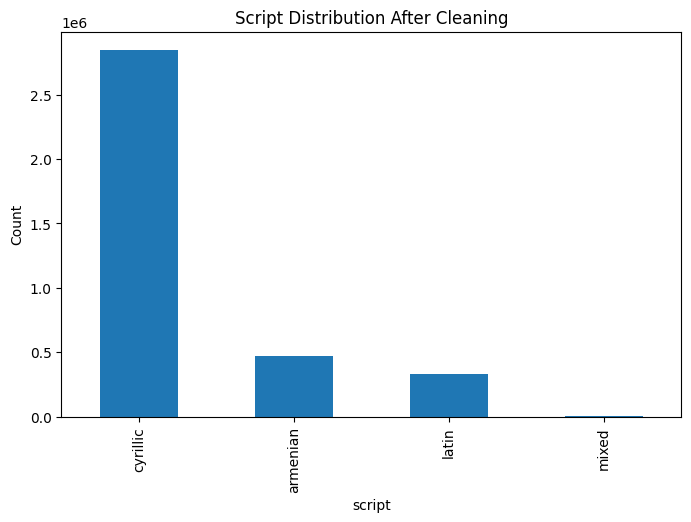

In [7]:
# ============================================================
# SCRIPT DISTRIBUTION
# ============================================================

script_counts = df['script'].value_counts()

print(script_counts)

plt.figure(figsize=(8,5))

script_counts.plot(kind='bar')

plt.title('Script Distribution After Cleaning')

plt.ylabel('Count')

plt.show()

In [8]:
# ============================================================
# NORMALIZATION EXAMPLES
# ============================================================

sample = df[
    [
        'party_name',
        'name_normalized',
        'name_no_legal',
        'name_latin'
    ]
].sample(30, random_state=42)

sample

,party_name,name_normalized,name_no_legal,name_latin
857090,ЖАНҰЗАҚОВ ҚАРШЫҒА ЕРҰЗАҚҰЛЫ,жанұзақов қаршыға ерұзақұлы,жанұзақов қаршыға ерұзақұлы,zhanuzakov karshyga eruzakuly
182037,ՆԵՈ ՄԵՏԱԼՍ ՀՈԼԴԻՆԳ ԼԻՄԻԹԵԴ,նեո մետալս հոլդինգ լիմիթեդ,նեո մետալս հոլդինգ լիմիթեդ,neo metals holding limited
3521273,Батсүх Базарваань,батсүх базарваань,батсүх базарваань,batsuh bazarvaan
3434813,Нямгэрэл Ёндонжамц,нямгэрэл е ндонжамц,нямгэрэл е ндонжамц,nyamgerel e ndonzhamts
1262155,ШАМШАЕВА АҚНҰР ЖҰМАШҚЫЗЫ,шамшаева ақнұр жұмашқызы,шамшаева ақнұр жұмашқызы,shamshaeva aknur zhumashkyzy
1850271,Передков Александр Вячеславович,передков александр вячеславович,передков александр вячеславович,peredkov aleksandr vyacheslavovich
2908585,октябрь жансая,октябрь жансая,октябрь жансая,oktyabr zhansaya
632442,BAĞIROV XALİQ SACƏT OĞLU,bag irov xali q sacət og lu,bag irov xali q sacət og lu,bag irov xali q sacet og lu
146985,Դավիթ Մուսայելյան,դավիթ մուսայելյան,դավիթ մուսայելյան,davit mousayelyan
2650978,Цэгмэд Сэнгээ,цэгмэд сэнгээ,цэгмэд сэнгээ,tsegmed sengee


In [9]:
# ============================================================
# LEGAL FORMS ANALYSIS
# ============================================================

legal_forms = [
    'ооо', 'зао', 'оао',
    'пао', 'llc', 'ltd',
    'inc', 'corp'
]

for form in legal_forms:

    cnt = (
        df['name_normalized']
        .str.contains(
            fr'\b{form}\b',
            regex=True,
            na=False
        )
        .sum()
    )

    print(f"{form}: {cnt:,}")

ооо: 0
зао: 0
оао: 0
пао: 0
llc: 73
ltd: 755
inc: 115
corp: 59


In [10]:
# ============================================================
# LEGAL FORM REMOVAL CHECK
# ============================================================

sample = df[
    df['name_normalized'] != df['name_no_legal']
]

sample = sample[
    [
        'party_name',
        'name_normalized',
        'name_no_legal'
    ]
].sample(30, random_state=42)

sample

,party_name,name_normalized,name_no_legal
2901479,Япон улс Initia Star Securities Inc,япон улс initia star securities inc,япон улс initia star securities
2928450,INNER MONGOLIA MENGKAI IMPORT EXPORT TRADING C...,inner mongolia mengkai import export trading c...,inner mongolia mengkai import export trading
2369899,Общество с ограниченной ответственностью Китай...,общество с ограниченнои ответственностью китаи...,общество с ограниченнои ответственностью китаи...
3131983,GLOBAL COKING COAL PTE.LTD.,global coking coal pte ltd,global coking coal pte
2030020,"ОАО ""Дос - Кредобанк""",оао дос кредобанк,дос кредобанк
3000072,WORLEY ENGINEERING SINGAPORE PTE.LTD,worley engineering singapore pte ltd,worley engineering singapore pte
2353736,ЗАО Биатекс,зао биатекс,биатекс
2307990,Частная компания ZorTechnologies Ltd.,частная компания zortechnologies ltd,частная компания zortechnologies
2282532,"1648 работников ФЛ ОАО ""Национальная электриче...",работников фл оао национальная электрическая с...,работников фл национальная электрическая сеть ...
2228960,"ООО ""Агросервис Азия""",ооо агросервис азия,агросервис азия


count    3.653581e+06
mean     2.269808e+01
std      8.309571e+00
min      0.000000e+00
25%      1.700000e+01
50%      2.200000e+01
75%      2.800000e+01
max      2.550000e+02
Name: name_length, dtype: float64


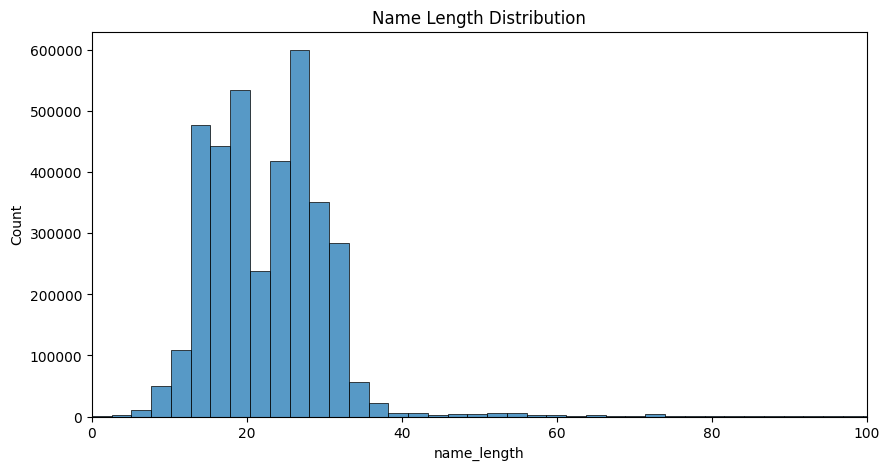

In [11]:
# ============================================================
# NAME LENGTH ANALYSIS
# ============================================================

df['name_length'] = (
    df['name_no_legal']
    .str.len()
)

print(df['name_length'].describe())

plt.figure(figsize=(10,5))

sns.histplot(
    df['name_length'],
    bins=100
)

plt.xlim(0, 100)

plt.title('Name Length Distribution')

plt.show()

In [12]:
# ============================================================
# SHORT NAMES
# ============================================================

short_names = df[
    df['name_length'] <= 5
]

print(f"Short names: {len(short_names):,}")

short_names[
    [
        'party_name',
        'name_no_legal'
    ]
].head(50)

Short names: 3,566


,party_name,name_no_legal
3974,«ՊՐԻՔՍ»,պրիքս
4004,«ԹԶՀ»,թզհ
4034,«ՀՈՒՇ»,հուշ
4102,«Տ-ՄԵԴ»,տ մեդ
4209,«ԹԶՀ»,թզհ
4288,«ԷՎԷ»,էվէ
4907,«ՀՈՒՇ»,հուշ
4930,«ՀՈՒՇ»,հուշ
8753,«Տ-ՄԵԴ»,տ մեդ
9014,«ՀԵՐԵՍ»,հերես


In [13]:
# ============================================================
# LONG NAMES
# ============================================================

long_names = df[
    df['name_length'] >= 100
]

print(f"Long names: {len(long_names):,}")

long_names[
    [
        'party_name'
    ]
].head(20)

Long names: 2,418


,party_name
1687353,Мамашев (өз Калоосу Менен Бошотуу Жөнүндөгү А...
1714608,Решение Ленинского Суда Г. Бишкек От 06.02.202...
1765952,"Учреждение ""Ысык-Атинский айыл окмоту Ысык-Ати..."
1766339,"Муниципальное учреждение ""Департамент транспор..."
1766452,"Учреждение ""Грозденский айыл окмоту Грозденско..."
1766769,"Государственное предприятие ""Дирекция по управ..."
1766805,"Государственное предприятие ""Кыргызавтожол- Се..."
1766820,"""Государственное учреждение ""Кадастр"" при Служ..."
1766825,"""Государственное учреждение ""Кадастр"" при Служ..."
1766834,"Учреждение ""Учебно-научно-производственный ком..."


In [14]:
# ============================================================
# TOKEN ANALYSIS
# ============================================================

tokens = []

for text in df['name_no_legal'].dropna():

    tokens.extend(text.split())

token_counts = Counter(tokens)

top_tokens = pd.DataFrame(
    token_counts.most_common(100),
    columns=['token', 'count']
)

top_tokens.head(30)

,token,count
0,lu,227466
1,og,226630
2,аи,95705
3,i,64620
4,хан,56085
5,կազմակերպություն,50793
6,անհայտ,50737
7,yev,35649
8,qizi,35035
9,n,31437


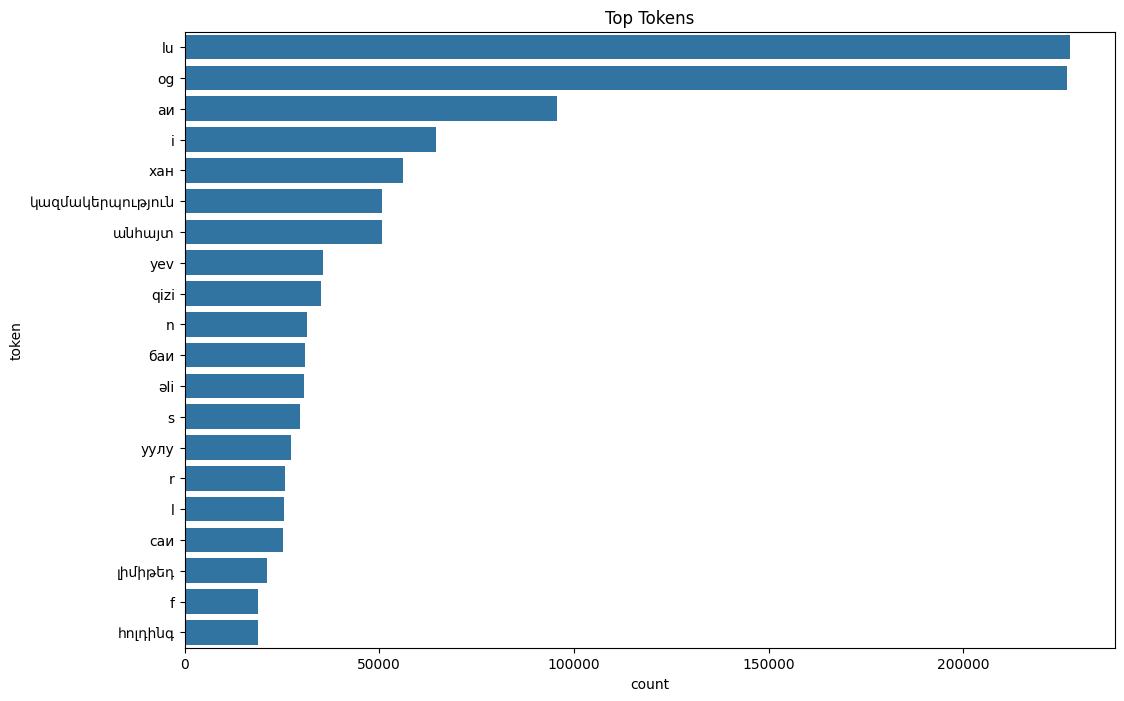

In [15]:
# ============================================================
# TOP TOKENS VISUALIZATION
# ============================================================

plt.figure(figsize=(12,8))

sns.barplot(
    data=top_tokens.head(20),
    x='count',
    y='token'
)

plt.title('Top Tokens')

plt.show()

In [16]:
# ============================================================
# RARE TOKENS
# ============================================================

rare_tokens = [
    token
    for token, count in token_counts.items()
    if count == 1
]

print(f"Rare tokens: {len(rare_tokens):,}")

print("\nExamples:")

print(rare_tokens[:50])

Rare tokens: 180,636

Examples:
['արզուման', 'սարկիսիան', 'սփորթիըն', 'անտիգա', 'բանուչյան', 'օգայ', 'էլիզբարյան', 'մելյան', 'ռազմիկի', 'սերկով', 'տարասովա', 'մարզպետ', 'քաղքցյան', 'ջոնիկ', 'կարաձաս', 'rayxan', 'abisalam', 'kamiiwa', 'tanfer', 'aspen', 'willard', 'ahsin', 'jelovchy', 'covdət', 'uravan', 'mogilevski', 'ferdosian', 'seyedmorteza', 'seyedmostafa', 'alfalahi', 'ghaith', 'sokounati', 'perevezentsev', 'ekelaka', 'chidiebere', 'bayramnejad', 'jafarolsadegh', 'xaspulat', 'shipaev', 'mattathur', 'izmailova', 'rzəi', 'madov', 'atahanov', 'murod', 'batova', 'kyesoo', 'səlsəl', 'səxər', 'hassannia']


In [17]:
# ============================================================
# TRANSLITERATION CHECK
# ============================================================

sample = df[
    [
        'party_name',
        'name_latin'
    ]
].sample(50, random_state=42)

sample

,party_name,name_latin
857090,ЖАНҰЗАҚОВ ҚАРШЫҒА ЕРҰЗАҚҰЛЫ,zhanuzakov karshyga eruzakuly
182037,ՆԵՈ ՄԵՏԱԼՍ ՀՈԼԴԻՆԳ ԼԻՄԻԹԵԴ,neo metals holding limited
3521273,Батсүх Базарваань,batsuh bazarvaan
3434813,Нямгэрэл Ёндонжамц,nyamgerel e ndonzhamts
1262155,ШАМШАЕВА АҚНҰР ЖҰМАШҚЫЗЫ,shamshaeva aknur zhumashkyzy
1850271,Передков Александр Вячеславович,peredkov aleksandr vyacheslavovich
2908585,октябрь жансая,oktyabr zhansaya
632442,BAĞIROV XALİQ SACƏT OĞLU,bag irov xali q sacet og lu
146985,Դավիթ Մուսայելյան,davit mousayelyan
2650978,Цэгмэд Сэнгээ,tsegmed sengee


In [18]:
# ============================================================
# UNIQUENESS REDUCTION
# ============================================================

cols = [
    'party_name',
    'name_normalized',
    'name_no_legal',
    'name_latin'
]

for col in cols:

    unique_count = df[col].nunique()

    print(f"{col}: {unique_count:,}")

party_name: 1,926,840
name_normalized: 1,753,932
name_no_legal: 1,753,908
name_latin: 1,750,005


In [19]:
# ============================================================
# NOISE REDUCTION
# ============================================================

original = df['party_name'].nunique()

normalized = df['name_normalized'].nunique()

reduced = original - normalized

print(f"Original unique names: {original:,}")

print(f"Normalized unique names: {normalized:,}")

print(f"Reduced variants: {reduced:,}")

print(f"Reduction ratio: {reduced / original * 100:.2f}%")

Original unique names: 1,926,840
Normalized unique names: 1,753,932
Reduced variants: 172,908
Reduction ratio: 8.97%


In [20]:
# ============================================================
# DUPLICATES AFTER PREPROCESSING
# ============================================================

duplicates = (
    df.groupby('name_no_legal')
    .size()
    .reset_index(name='count')
    .sort_values('count', ascending=False)
)

duplicates.head(30)

,name_no_legal,count
1748850,անհայտ կազմակերպություն,50737
1752335,նեո մետալս հոլդինգ լիմիթեդ,14496
1752016,միրզաազիզ մուսախանով,11003
1753171,սվետլանա երշովա,8870
1749197,արդյունաբերական ընկերություն բը,8172
1752538,պրոմիշլեննայա կոմպանիա,5661
1752336,նեո մետալս հոլդինգ լիմիթեդ բաժնետոմսերով սահմա...,3675
1753877,ֆայրբըրդ մենեջմենտ սպը,2760
1750368,եվգենիա վասիլեվա,2714
1748571,ալեքսանդր տրունով,2714


In [21]:
# ============================================================
# PARTY PUBLIC ID ANALYSIS
# ============================================================

print("="*60)
print("PARTY PUBLIC ID")
print("="*60)

not_null = df['party_public_id'].notna().sum()

print(f"Rows with labels: {not_null:,}")

print(f"Ratio: {not_null / len(df) * 100:.2f}%")

print("\nUnique IDs:")

print(df['party_public_id'].nunique())

PARTY PUBLIC ID
Rows with labels: 112,141
Ratio: 3.07%

Unique IDs:
53427


In [22]:
# ============================================================
# ENTITY CLUSTER SIZES
# ============================================================

clusters = (
    df[df['party_public_id'].notna()]
    .groupby('party_public_id')
    .size()
)

print(clusters.describe())

count    53427.000000
mean         2.098957
std         61.638288
min          1.000000
25%          1.000000
50%          1.000000
75%          2.000000
max      13783.000000
dtype: float64


In [23]:
# ============================================================
# SAVE PROCESSED DATASET
# ============================================================

save_path = "../data/processed/processed_dataset.parquet"

df.to_parquet(save_path)

print(f"Saved to: {save_path}")

Saved to: ../data/processed/processed_dataset.parquet


**Выводы:**

Первичная очистка и нормализация прошли успешно.

Удалось:

- очистить мусор;
- стандартизировать имена;
- сократить число вариантов;
- подготовить данные для ML;
- выделить главные проблемные зоны.

Сейчас датасет уже пригоден для:

- построения candidate generation;
- TF-IDF поиска;
- embeddings;
- обучения matching-моделей;
- построения deduplication pipeline.

Но перед полноценным ML необходимо:

- улучшить транслитерацию; (уже сделано)
- доработать нормализацию;
- стабилизировать юридические формы;
- построить качественный blocking;
- валидировать party_public_id.